# Analyzing the Relationship Between Job satisfaction in Employees and Different Factors 


## Abstract

**complete when finished

## Authors

Team Members: Roxana Behjat, Taishi Aizawa, Rajveer Barring, Brandon Su

## Background and Prior Work

Our group is investigating the factors that drive job satisfaction, as employee satisfaction is a key indicator of organizational health, strength, and productivity. The goal is to gain a more targeted, in-depth understanding of the workplace drivers of satisfaction by investigating how job satisfaction varies across departments and its relationship to performance ratings, promotion history, and other contributing factors. Findings from this type of analysis can help inform business strategies and assist organizations in identifying departments with lower satisfaction to target. This makes our research and findings valuable, as they can be used to help companies in these kinds of movements; our original motivation was to find a way to boost organizational health, and we found this to be a good way to look into it. 



## Hypothesis


We hypothesize job satisfaction is not evenly distributed across departments and that factors related to career growth, such as promotion history, will be positively associated with satisfaction. We expect that the specific parameters we have chosen, such as benefits and employee retention, will be positively correlated with employee satisfaction. While we acknowledge that not all employee data will necessarily have a significant impact on overall employee satisfaction, we hypothesize that certain factors strongly influence how employees view their company. 


## Data

### Data overview

- **Dataset: Global Satisfaction Index Results by Agency (US Office of Personnel Management)**
  - **Dataset Name:** Employee Performance and Productivity Data by mexwell
  - **Link to the dataset:** https://www.kaggle.com/datasets/mexwell/employee-performance-and-productivity-data/data
  - **Number of observations:** 100,000 employees
  - **Number of variables:** 20 columns (1 datetime, 1 bool, 2 float, 4 categorical/string, 12 int)
  - **Description of the variables:**

 - `Employee_ID` (string): Unique identifier for each employee. Treated as an identifier, not a numeric variable for calculation.
- `Department` (string): Department in which the employee works, such as Sales, HR, or IT.
- `Gender` (string): Gender of the employee, such as Male, Female, or Other.
- `Age` (integer): Employee's age, ranging from 22 to 60.
- `Job_Title` (string): Role held by the employee, such as Manager, Analyst, or Developer.
- `Hire_Date` (datetime): Date the employee was hired.
- `Years_At_Company` (integer): Number of years the employee has worked at the company.
- `Education_Level` (string): Highest educational qualification, such as High School, Bachelor, Master, or PhD.
- `Performance_Score` (integer, 1–5): Employee's performance rating on a 1 to 5 scale.
- `Monthly_Salary` (float, USD): Employee's monthly salary in U.S. dollars.
- `Work_Hours_Per_Week` (integer): Number of hours the employee works per week.
- `Projects_Handled` (integer): Total number of projects handled by the employee.
- `Overtime_Hours` (integer): Total overtime hours worked by the employee in the last year.
- `Sick_Days` (integer): Number of sick days taken by the employee.
- `Remote_Work_Frequency` (integer, 0–100): Percentage of time the employee works remotely.
- `Team_Size` (integer): Number of people in the employee's team.
- `Training_Hours` (integer): Number of hours the employee spent in training.
- `Promotions` (integer): Number of promotions the employee has received during their tenure.
- `Employee_Satisfaction_Score` (float, 1.0–5.0): Employee satisfaction rating on a 1.0 to 5.0 scale.
- `Resigned` (boolean): Whether the employee has resigned from the company.



- **Shortcomings of this dataset:**
  - The data is hypothetical, not from a research study but instead artificially genrated.


In [7]:
import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from kagglehub import KaggleDatasetAdapter

df_raw = kagglehub.dataset_load(
    KaggleDatasetAdapter.PANDAS,
    "mexwell/employee-performance-and-productivity-data",
    "Extended_Employee_Performance_and_Productivity_Data.csv",
)

df_raw.head()


,Employee_ID,Department,Gender,Age,Job_Title,Hire_Date,Years_At_Company,Education_Level,Performance_Score,Monthly_Salary,Work_Hours_Per_Week,Projects_Handled,Overtime_Hours,Sick_Days,Remote_Work_Frequency,Team_Size,Training_Hours,Promotions,Employee_Satisfaction_Score,Resigned
0,1,IT,Male,55,Specialist,2022-01-19 08:03:05.556036,2,High School,5,6750.0,33,32,22,2,0,14,66,0,2.63,False
1,2,Finance,Male,29,Developer,2024-04-18 08:03:05.556036,0,High School,5,7500.0,34,34,13,14,100,12,61,2,1.72,False
2,3,Finance,Male,55,Specialist,2015-10-26 08:03:05.556036,8,High School,3,5850.0,37,27,6,3,50,10,1,0,3.17,False
3,4,Customer Support,Female,48,Analyst,2016-10-22 08:03:05.556036,7,Bachelor,2,4800.0,52,10,28,12,100,10,0,1,1.86,False
4,5,Engineering,Female,36,Analyst,2021-07-23 08:03:05.556036,3,Bachelor,2,4800.0,38,11,29,13,100,15,9,1,1.25,False


The first thing we did was move the employee ID to be the index, and then take a look at the shape of the data:

In [8]:
df_raw.set_index('Employee_ID', inplace=True)
print(f"Full dataset shape: {df_raw.shape}")
print()

print(f"  Rows (observations): {df_raw.shape[0]}")
print(f"  Columns (variables): {df_raw.shape[1]}")
print()
print(f"  Departments: {df_raw['Department'].unique()}")
print(f"  Job Titles: {df_raw['Job_Title'].unique()}")

df_raw.head()


Full dataset shape: (100000, 19)

  Rows (observations): 100000
  Columns (variables): 19

  Departments: ['IT' 'Finance' 'Customer Support' 'Engineering' 'Marketing' 'HR'
 'Operations' 'Sales' 'Legal']
  Job Titles: ['Specialist' 'Developer' 'Analyst' 'Manager' 'Technician' 'Engineer'
 'Consultant']


,Department,Gender,Age,Job_Title,Hire_Date,Years_At_Company,Education_Level,Performance_Score,Monthly_Salary,Work_Hours_Per_Week,Projects_Handled,Overtime_Hours,Sick_Days,Remote_Work_Frequency,Team_Size,Training_Hours,Promotions,Employee_Satisfaction_Score,Resigned
Employee_ID,,,,,,,,,,,,,,,,,,,
1,IT,Male,55,Specialist,2022-01-19 08:03:05.556036,2,High School,5,6750.0,33,32,22,2,0,14,66,0,2.63,False
2,Finance,Male,29,Developer,2024-04-18 08:03:05.556036,0,High School,5,7500.0,34,34,13,14,100,12,61,2,1.72,False
3,Finance,Male,55,Specialist,2015-10-26 08:03:05.556036,8,High School,3,5850.0,37,27,6,3,50,10,1,0,3.17,False
4,Customer Support,Female,48,Analyst,2016-10-22 08:03:05.556036,7,Bachelor,2,4800.0,52,10,28,12,100,10,0,1,1.86,False
5,Engineering,Female,36,Analyst,2021-07-23 08:03:05.556036,3,Bachelor,2,4800.0,38,11,29,13,100,15,9,1,1.25,False


We then looked at what each column's dtype was:

In [9]:
print("Column names and dtypes:")
print(df_raw.dtypes)
print()

Column names and dtypes:
Department                      object
Gender                          object
Age                              int64
Job_Title                       object
Hire_Date                       object
Years_At_Company                 int64
Education_Level                 object
Performance_Score                int64
Monthly_Salary                 float64
Work_Hours_Per_Week              int64
Projects_Handled                 int64
Overtime_Hours                   int64
Sick_Days                        int64
Remote_Work_Frequency            int64
Team_Size                        int64
Training_Hours                   int64
Promotions                       int64
Employee_Satisfaction_Score    float64
Resigned                          bool
dtype: object



We then adjusted accordingly, making each column the appropriate string, datetime, etc.

In [10]:
df_raw["Job_Title"] = df_raw["Job_Title"].astype("string")
df_raw["Department"] = df_raw["Department"].astype("string")
df_raw["Education_Level"] = df_raw["Education_Level"].astype("string")
df_raw["Gender"] = df_raw["Gender"].astype("string")
df_raw["Gender"] = df_raw["Gender"].astype("string")
df_raw['Hire_Date'] = pd.to_datetime(df_raw['Hire_Date'])

In [11]:
print("Column names and dtypes:")
print(df_raw.dtypes)
print()

Column names and dtypes:
Department                     string[python]
Gender                         string[python]
Age                                     int64
Job_Title                      string[python]
Hire_Date                      datetime64[ns]
Years_At_Company                        int64
Education_Level                string[python]
Performance_Score                       int64
Monthly_Salary                        float64
Work_Hours_Per_Week                     int64
Projects_Handled                        int64
Overtime_Hours                          int64
Sick_Days                               int64
Remote_Work_Frequency                   int64
Team_Size                               int64
Training_Hours                          int64
Promotions                              int64
Employee_Satisfaction_Score           float64
Resigned                                 bool
dtype: object



We then took a look at the number of missing values in the dataset, and there are none.

Missing values per column:
Empty DataFrame
Columns: [missing_count, missing_pct]
Index: []

No missing values found in any column.


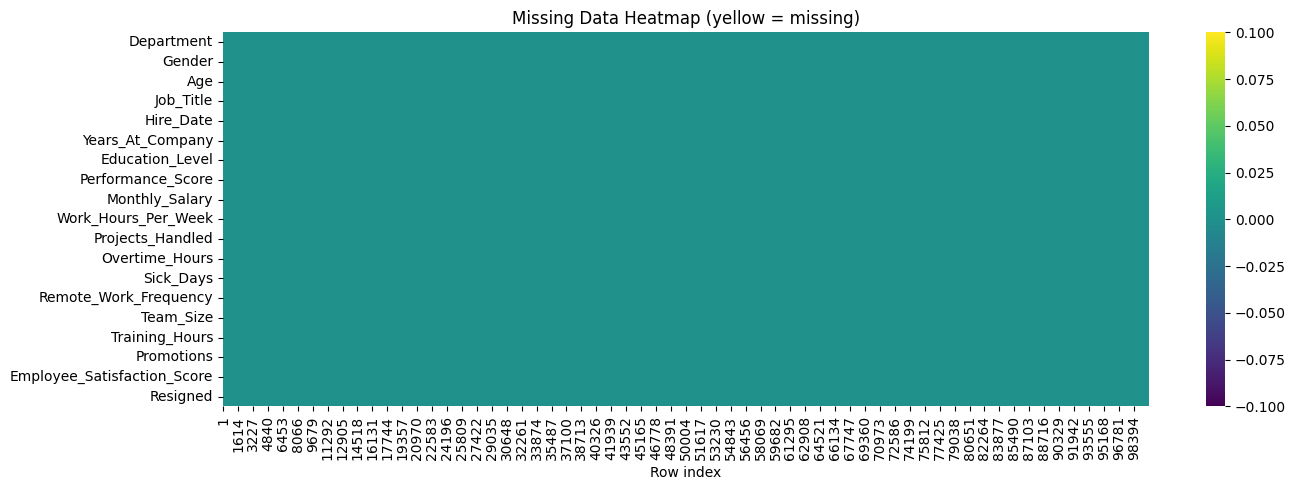


Rows with at least one missing value: 0 / 100000 (0.00%)


In [12]:
missing_counts = df_raw.isnull().sum()
missing_pct = (df_raw.isnull().sum() / len(df_raw)) * 100
missing_summary = pd.DataFrame({
    'missing_count': missing_counts,
    'missing_pct': missing_pct
}).sort_values('missing_count', ascending=False)

print("Missing values per column:")
print(missing_summary[missing_summary['missing_count'] > 0])
print()
if missing_summary['missing_count'].sum() == 0:
    print("No missing values found in any column.")
else:
    print(f"Total missing values: {missing_summary['missing_count'].sum()}")

fig, ax = plt.subplots(figsize=(14, 5))
sns.heatmap(df_raw.isnull().T, cbar=True, yticklabels=True, cmap='viridis', ax=ax)
ax.set_title('Missing Data Heatmap (yellow = missing)')
ax.set_xlabel('Row index')
plt.tight_layout()
plt.show()

rows_with_missing = df_raw.isnull().any(axis=1).sum()
print(f"\nRows with at least one missing value: {rows_with_missing} / {len(df_raw)} "
      f"({rows_with_missing / len(df_raw):.2%})")

## Results

### Exploratory Data Analysis


### Previous Analysis Done


## Results and Takeaways



### Potential Limitations and Shortcomings